# Social Content Analysis
## Sentiment Analysis & Emotion Analysis
### Reddit Olympics Dataset

---
## Installazione dipendenze

In [ ]:
!pip install vaderSentiment transformers scipy tqdm -q
!pip install wordcloud -q
!pip install nltk -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


---
## Import librerie

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
import warnings
import urllib.request, csv
from tqdm import tqdm
import seaborn as sns
from wordcloud import WordCloud
from matplotlib.patches import Patch

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch
from tqdm import tqdm
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')
tqdm.pandas()

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## DATA LOADING VIA Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/SMA_Loreti_Pegoraro'
DATA_COMMENTS = f'{DRIVE_BASE}/Data/reddit_comments.csv'
DATA_OUT = f'{DRIVE_BASE}/Data/reddit_comments_sentiment.csv'

Mounted at /content/drive


In [ ]:
comments_df = pd.read_csv(DATA_COMMENTS)

print(f'Comments loaded : {len(comments_df)}')
print(f'Subreddit : {comments_df["subreddit"].unique().tolist()}')
comments_df.head(3)

Comments loaded : 24756
Subreddit : ['olympics', 'hockey', 'FigureSkating', 'Curling', 'skiing', 'snowboarding', 'biathlon']


,post_id,comment_id,parent_id,author,body,score,created_utc,subreddit,depth
0,1q163rv,nxuc7tu,t1_nxfh2oo,keyser1981,"Agreed but also: Hosting ""The Olympics"" while ...",2,2026-01-05 16:39:32,olympics,0
1,1q163rv,nxu0am2,t1_nx3firv,Zestyclose_Ant_3039,Pushed housing prices in the area out of reach...,1,2026-01-05 15:43:58,olympics,0
2,1q163rv,nxfh2oo,t3_1q163rv,EnvironmentalWar,The United States should be banned from compet...,1,2026-01-03 12:40:12,olympics,0


---
## text preprocessing

In [ ]:
def remove_emojis(text):
    # Reference: https://gist.github.com/slowkow/7a7f61f495e3dbb7e3d767f97bd7304b
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002500-\U00002BEF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d\u23cf\u23e9\u231a\ufe0f\u3030"
    "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_mentions(tweet): return re.sub("@[A-Za-z0-9_]+", "", tweet)
def remove_hashtags(tweet): return re.sub("#[A-Za-z0-9_]+", "", tweet)
def remove_urls(tweet): return re.sub(r'https?://\S+|www\.\S+', '', tweet)
def remove_spaces(tweet): return re.sub(' +', ' ', tweet)
def lower_case(tweet):return tweet.lower()

def adjust_spaces(tweet):
    tmp = re.sub(r"\s([\,\.\?\!\:\;\)\]\}\'\"\"\'])", r"\1", tweet)
    return re.sub(r"([ \(\[\{\"\"\'])\s", r"\1", tmp)

def remove_initial_symbols(tweet):
    tmp = re.sub(r'^([\W*\s*])(?!\1)([\W*\s*])(\1\2)*\1?', '', tweet)
    return re.sub(r'^\s*', '', tmp)

def adjust_accents(tweet):
    tmp = re.sub("e\'", "è", tweet)
    return re.sub("a\'", "à", tmp)

regex_str = [
    r'<[^>]+>', r'(?:@[\w_]+)', r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)",
    r'http[s]?://(?:[a-z]|[0-9]|[$-_@.&+]|[!*,]|(?:%[0-9a-f][0-9a-f]))+',
    r'(?:(?:\d+,?)+(?:\.?\d+)?)', r'(?:[\w_]+)', r'(?:\S)'
]
tokens_re = re.compile(r'(' + '|'.join(regex_str) + ')', re.VERBOSE | re.IGNORECASE)

def tokenize(s): return tokens_re.findall(s)
def preprocess_tokenize(t):  return " ".join(tokenize(t))

print('Preprocessing functions defined.')

Preprocessing functions defined.


In [ ]:
comments_df['text_clean'] = (
    comments_df['body']
    .apply(lower_case)
    .apply(preprocess_tokenize)
    .apply(remove_emojis)
    .apply(remove_mentions)
    .apply(remove_hashtags)
    .apply(remove_urls)
    .apply(remove_spaces)
    .apply(adjust_spaces)
    .apply(remove_initial_symbols)
    .apply(adjust_accents)
)

print(f'Preprocessing completed on {len(comments_df)} comments.')
print(f'  original  : {comments_df["body"].iloc[0]}')
print(f'  text_clean : {comments_df["text_clean"].iloc[0]}')

Preprocessing completed on 24756 comments.
  original  : Agreed but also: Hosting "The Olympics" while the world is currently at war, is a fukken joke. I said what I said. We're all just perpetuating the status quo, perpetuating capitalism, and kicking the can down the road for young people to deal with. Holy. Christ.
  text_clean : agreed but also: hosting"the olympics"while the world is currently at war, is a fukken joke. i said what i said. wère all just perpetuating the status quo, perpetuating capitalism, and kicking the can down the road for young people to deal with. holy. christ.


---
## Sentiment Analysis — VADER


| Compound | Label |
|---|---|
| ≥ 0.05 | positive |
| ≤ -0.05 | negative |
| altro | neutral |

In [ ]:
sid_obj = SentimentIntensityAnalyzer()

def vader_score(sentence):
    if not isinstance(sentence, str) or sentence.strip() == '':
        return 0.0
    return sid_obj.polarity_scores(sentence)['compound']

def vader_label(compound_score):
    if compound_score >= 0.05: return 'positive'
    elif compound_score <= -0.05: return 'negative'
    else:  return 'neutral'

# Test qualitativo
test_sentences = [
    "what an amazing performance by the athletes!",
    "the scoring system is completely unfair.",
    "the competition starts at 3pm tomorrow.",
    "incredible gold medal for team usa!",
    "i can't believe how badly they judged that routine."
]
print('Test VADER:')
for s in test_sentences:
    score = vader_score(s)
    print(f'  [{vader_label(score):8s} | {score:+.3f}] {s}')

Test VADER:
  [positive | +0.624] what an amazing performance by the athletes!
  [negative | -0.526] the scoring system is completely unfair.
  [neutral  | +0.000] the competition starts at 3pm tomorrow.
  [positive | +0.568] incredible gold medal for team usa!
  [positive | +0.372] i can't believe how badly they judged that routine.


In [ ]:
print('Calculation of VADER on all comments...')
comments_df['vader_compound'] = comments_df['text_clean'].progress_apply(vader_score)
comments_df['vader_label']    = comments_df['vader_compound'].apply(vader_label)

print(f'\nVADER Distribution:')
print(comments_df['vader_label'].value_counts())
print(f'\nMedium compound: {comments_df["vader_compound"].mean():.4f}')

Calculation of VADER on all comments...


100%|██████████| 24756/24756 [00:11<00:00, 2064.16it/s]


VADER Distribution:
vader_label
positive    13652
neutral      5822
negative     5282
Name: count, dtype: int64

Medium compound: 0.2329


### visualization : Waffle chart sentiment globale

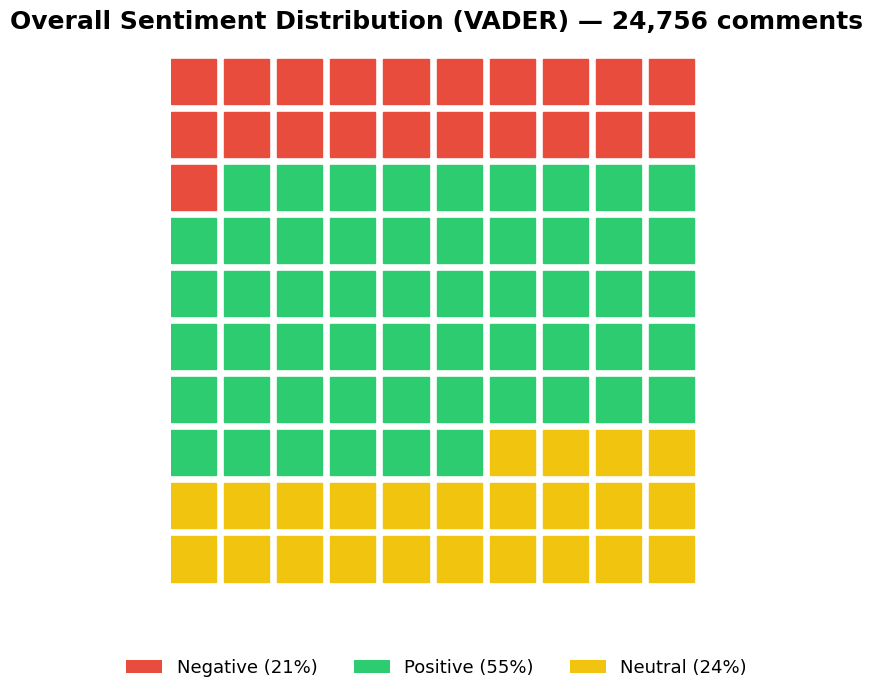

In [ ]:
vader_counts = comments_df['vader_label'].value_counts()
total = vader_counts.sum()

neg = int(vader_counts.get('negative', 0))
pos = int(vader_counts.get('positive', 0))
neu = int(vader_counts.get('neutral',  0))

cells = 100
cols_w = 10
n_neg  = round(neg / total * cells)
n_pos = round(pos / total * cells)
n_neu = cells - n_neg - n_pos
sequence = ['#e74c3c'] * n_neg + ['#2ecc71'] * n_pos + ['#f1c40f'] * n_neu

fig, ax = plt.subplots(figsize=(12, 7))

for idx, color in enumerate(sequence):
    r, c = divmod(idx, cols_w)
    ax.add_patch(plt.Rectangle((c, -r), 0.85, 0.85, color=color))

ax.set_xlim(0, cols_w)
ax.set_ylim(-(cells // cols_w), 1)
ax.set_aspect('equal')
ax.axis('off')

ax.set_title(
    f'Overall Sentiment Distribution (VADER) — {total:,} comments',
    fontsize=18, pad=16, fontweight='bold'
)

legend_elements = [
    Patch(facecolor='#e74c3c', label=f'Negative ({neg/total:.0%})'),
    Patch(facecolor='#2ecc71', label=f'Positive ({pos/total:.0%})'),
    Patch(facecolor='#f1c40f', label=f'Neutral ({neu/total:.0%})'),
]

ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    fontsize=13,
    framealpha=0
)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/sentiment_waffle_global.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Waffle chart per subreddit

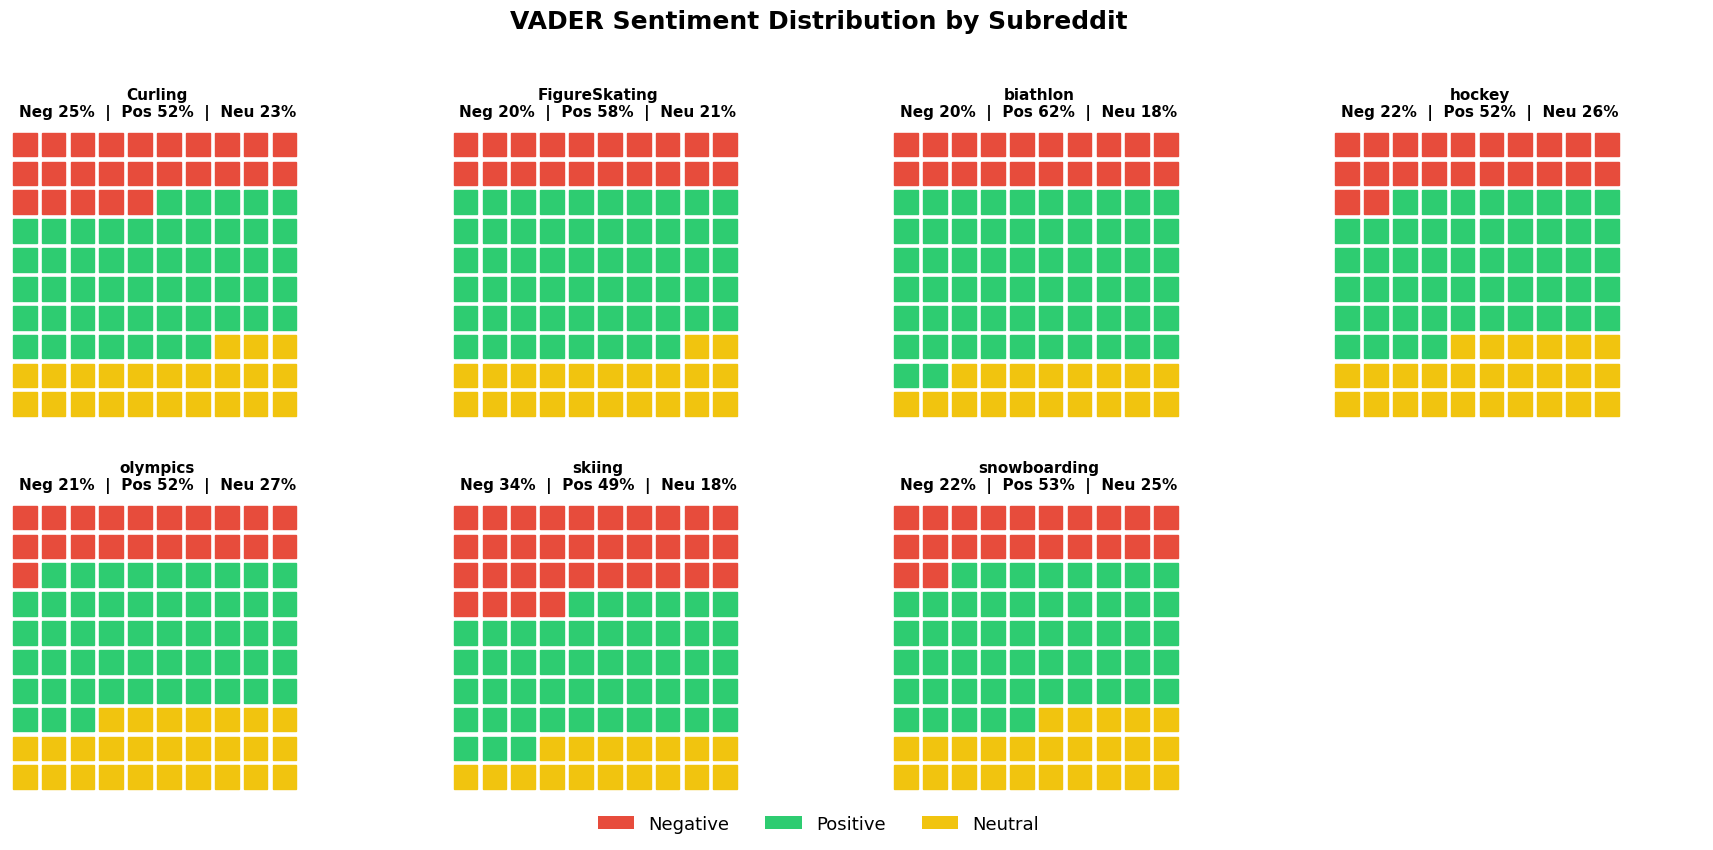

In [ ]:
subreddits_list = sorted(comments_df['subreddit'].unique())
n_cols = 4
n_rows = -(-len(subreddits_list) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

cells = 100
cols_w = 10

for i, sub in enumerate(subreddits_list):
    sub_df = comments_df[comments_df['subreddit'] == sub]
    counts = sub_df['vader_label'].value_counts()
    total = counts.sum()

    neg = int(counts.get('negative', 0))
    pos = int(counts.get('positive', 0))
    neu = int(counts.get('neutral',  0))

    n_neg = round(neg / total * cells)
    n_pos = round(pos / total * cells)
    n_neu = cells - n_neg - n_pos
    sequence = ['#e74c3c'] * n_neg + ['#2ecc71'] * n_pos + ['#f1c40f'] * n_neu

    ax = axes[i]
    for idx, color in enumerate(sequence):
        r, c = divmod(idx, cols_w)
        ax.add_patch(plt.Rectangle((c, -r), 0.82, 0.82, color=color))

    ax.set_xlim(-0.1, cols_w + 0.1)
    ax.set_ylim(-(cells // cols_w), 1)
    ax.set_aspect('equal')
    ax.axis('off')

    ax.set_title(
        f'{sub}\nNeg {neg/total:.0%}  |  Pos {pos/total:.0%}  |  Neu {neu/total:.0%}',
        fontsize=11, pad=8, fontweight='bold'
    )

for j in range(len(subreddits_list), len(axes)):
    axes[j].axis('off')

legend_elements = [
    Patch(facecolor='#e74c3c', label='Negative'),
    Patch(facecolor='#2ecc71', label='Positive'),
    Patch(facecolor='#f1c40f', label='Neutral'),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    fontsize=13,
    framealpha=0,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    'VADER Sentiment Distribution by Subreddit',
    fontsize=18,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/sentiment_waffle_subreddit.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

---
## Sentiment Analysis — RoBERTa



In [ ]:
MODEL_ID = 'cardiffnlp/twitter-roberta-base-sentiment'

print(f'Loading model: {MODEL_ID}')
roberta_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
roberta_model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
roberta_model.eval()

mapping_link = 'https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/sentiment/mapping.txt'
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split('\n')
    csvreader = csv.reader(html, delimiter='\t')
roberta_labels = [row[1] for row in csvreader if len(row) > 1]
print(f'Labels RoBERTa: {roberta_labels}')

Loading model: cardiffnlp/twitter-roberta-base-sentiment


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labels RoBERTa: ['negative', 'neutral', 'positive']


In [ ]:
def roberta_sentiment(text, max_length=512):
    if not isinstance(text, str) or text.strip() == '':
        return 'neutral', {'negative': 0.0, 'neutral': 1.0, 'positive': 0.0}

    encoded = roberta_tokenizer(
        text, return_tensors='pt', truncation=True, max_length=max_length
    )
    with torch.no_grad():
        output = roberta_model(**encoded)

    scores = softmax(output[0][0].numpy())
    ranking = np.argsort(scores)[::-1]
    top_label = roberta_labels[ranking[0]]
    scores_dict = {roberta_labels[i]: float(scores[i]) for i in range(len(roberta_labels))}
    return top_label, scores_dict

# test
test_sentences = [
    "what an amazing performance by the athletes!",
    "the scoring system is completely unfair.",
    "the competition starts at 3pm tomorrow."
]
print('Test RoBERTa:')
for s in test_sentences:
    label, scores = roberta_sentiment(s)
    print(f'  [{label:8s}] pos={scores["positive"]:.3f} neu={scores["neutral"]:.3f} neg={scores["negative"]:.3f} | {s}')

Test RoBERTa:
  [positive] pos=0.984 neu=0.014 neg=0.002 | what an amazing performance by the athletes!
  [negative] pos=0.002 neu=0.025 neg=0.972 | the scoring system is completely unfair.
  [neutral ] pos=0.087 neu=0.900 neg=0.013 | the competition starts at 3pm tomorrow.


In [ ]:
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from tqdm import tqdm
import logging
logging.disable(logging.CRITICAL)

print('Calculation of RoBERTa all comments...')
results = []
for text in tqdm(comments_df['text_clean'], desc='RoBERTa'):
    label, scores = roberta_sentiment(text)
    results.append({
        'roberta_label'  : label,
        'roberta_positive' : scores.get('positive', 0.0),
        'roberta_neutral'  : scores.get('neutral',  0.0),
        'roberta_negative' : scores.get('negative', 0.0),
    })

roberta_df= pd.DataFrame(results)
comments_df = pd.concat([comments_df.reset_index(drop=True), roberta_df], axis=1)

print(f'\nDistribution of RoBERTa:')
print(comments_df['roberta_label'].value_counts())

Calculation of RoBERTa all comments...


RoBERTa: 100%|██████████| 24756/24756 [1:32:16<00:00,  4.47it/s]



Distribution of RoBERTa:
roberta_label
neutral     11027
positive     7312
negative     6417
Name: count, dtype: int64


---
## VADER vs RoBERTa

In [ ]:
agreement = (comments_df['vader_label'] == comments_df['roberta_label']).mean()
print(f'VADER vs RoBERTa Agreement: {agreement:.2%}')

confusion = pd.crosstab(
    comments_df['roberta_label'],
    comments_df['vader_label'],
    rownames=['RoBERTa'],
    colnames=['VADER']
)
print('\nConfusion matrix:')
print(confusion)

VADER vs RoBERTa Agreement: 57.57%

Confusion matrix:
VADER     negative  neutral  positive
RoBERTa                              
negative      3469      898      2050
neutral       1565     4321      5141
positive       248      603      6461


###  visualizzazione — Heatmap confusion matrix

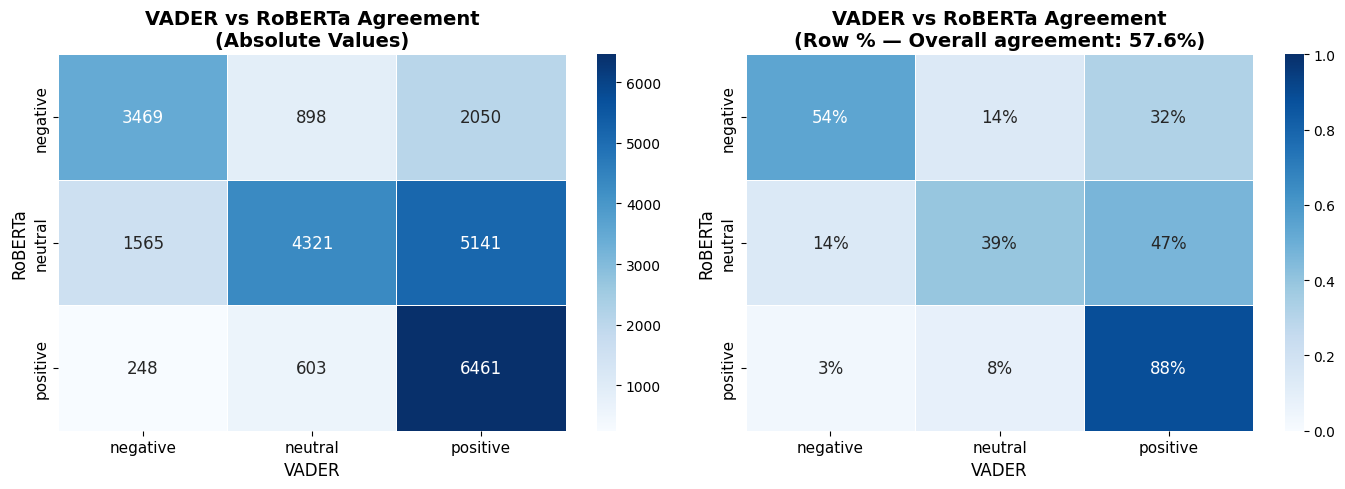

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    annot_kws={"size": 12},
    ax=axes[0]
)

axes[0].set_title(
    'VADER vs RoBERTa Agreement\n(Absolute Values)',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('VADER', fontsize=12)
axes[0].set_ylabel('RoBERTa', fontsize=12)
axes[0].tick_params(labelsize=11)

confusion_pct = confusion.div(confusion.sum(axis=1), axis=0)

sns.heatmap(
    confusion_pct,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    linewidths=0.5,
    vmin=0,
    vmax=1,
    annot_kws={"size": 12},
    ax=axes[1]
)

axes[1].set_title(
    f'VADER vs RoBERTa Agreement\n(Row % — Overall agreement: {agreement:.1%})',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('VADER', fontsize=12)
axes[1].set_ylabel('RoBERTa', fontsize=12)
axes[1].tick_params(labelsize=11)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/sentiment_vader_roberta_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

---
## Sentiment per subreddit

Sentiment by subreddit:
               n_comments  vader_mean  vader_std  pct_positive  pct_neutral  \
subreddit                                                                     
skiing                346       0.093      0.541         0.182        0.393   
Curling              2307       0.182      0.481         0.203        0.501   
hockey               3258       0.196      0.467         0.215        0.478   
snowboarding          264       0.199      0.439         0.223        0.458   
olympics             8617       0.214      0.469         0.301        0.451   
FigureSkating        7260       0.268      0.501         0.343        0.410   
biathlon             2704       0.309      0.491         0.348        0.445   

               pct_negative  
subreddit                    
skiing                0.425  
Curling               0.296  
hockey                0.307  
snowboarding          0.318  
olympics              0.249  
FigureSkating         0.248  
biathlon              0.

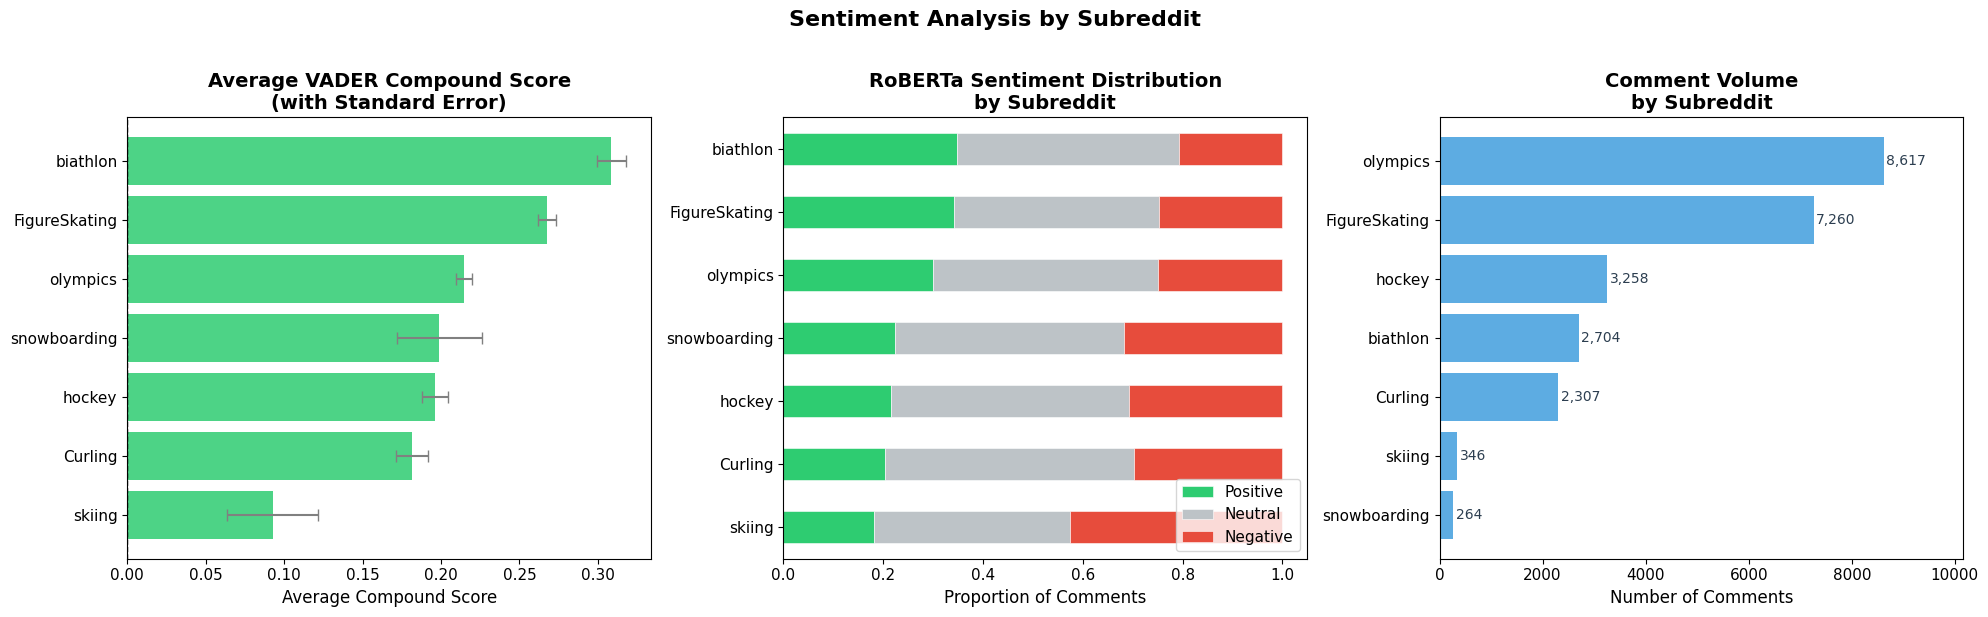

In [ ]:
sub_sentiment = comments_df.groupby('subreddit').agg(
    n_comments = ('body', 'count'),
    vader_mean = ('vader_compound', 'mean'),
    vader_std = ('vader_compound', 'std'),
    pct_positive = ('roberta_label', lambda x: (x == 'positive').mean()),
    pct_neutral = ('roberta_label', lambda x: (x == 'neutral').mean()),
    pct_negative = ('roberta_label', lambda x: (x == 'negative').mean()),
).sort_values('vader_mean', ascending=True)

print('Sentiment by subreddit:')
print(sub_sentiment.round(3))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# VADER mean
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in sub_sentiment['vader_mean']]

axes[0].barh(
    sub_sentiment.index,
    sub_sentiment['vader_mean'],
    xerr=sub_sentiment['vader_std'] / np.sqrt(sub_sentiment['n_comments']),
    color=colors, alpha=0.85, ecolor='gray', capsize=4
)

axes[0].axvline(0, color='black', linewidth=1, linestyle='--')

axes[0].set_title(
    'Average VADER Compound Score\n(with Standard Error)',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('Average Compound Score', fontsize=12)
axes[0].tick_params(labelsize=11)

# RoBERTa distribution
sub_sentiment[['pct_positive', 'pct_neutral', 'pct_negative']].plot(
    kind='barh',
    stacked=True,
    ax=axes[1],
    color=['#2ecc71', '#bdc3c7', '#e74c3c'],
    edgecolor='white',
    linewidth=0.4
)

axes[1].set_title(
    'RoBERTa Sentiment Distribution\nby Subreddit',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('Proportion of Comments', fontsize=12)
axes[1].legend(
    ['Positive', 'Neutral', 'Negative'],
    loc='lower right',
    fontsize=11
)
axes[1].tick_params(labelsize=11)
axes[1].set_ylabel('')

# volume
sub_vol = sub_sentiment['n_comments'].sort_values(ascending=True)

axes[2].barh(
    sub_vol.index,
    sub_vol.values,
    color='#3498db',
    alpha=0.8
)

for i, (idx, val) in enumerate(sub_vol.items()):
    axes[2].text(
        val + 50,
        i,
        f'{val:,}',
        va='center',
        fontsize=10,
        color='#2c3e50'
    )

axes[2].set_title(
    'Comment Volume\nby Subreddit',
    fontsize=14,
    fontweight='bold'
)
axes[2].set_xlabel('Number of Comments', fontsize=12)
axes[2].set_xlim(0, sub_vol.max() * 1.18)
axes[2].tick_params(labelsize=11)

plt.suptitle(
    'Sentiment Analysis by Subreddit',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/sentiment_per_subreddit.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

---
## Word Cloud: positive vs negative

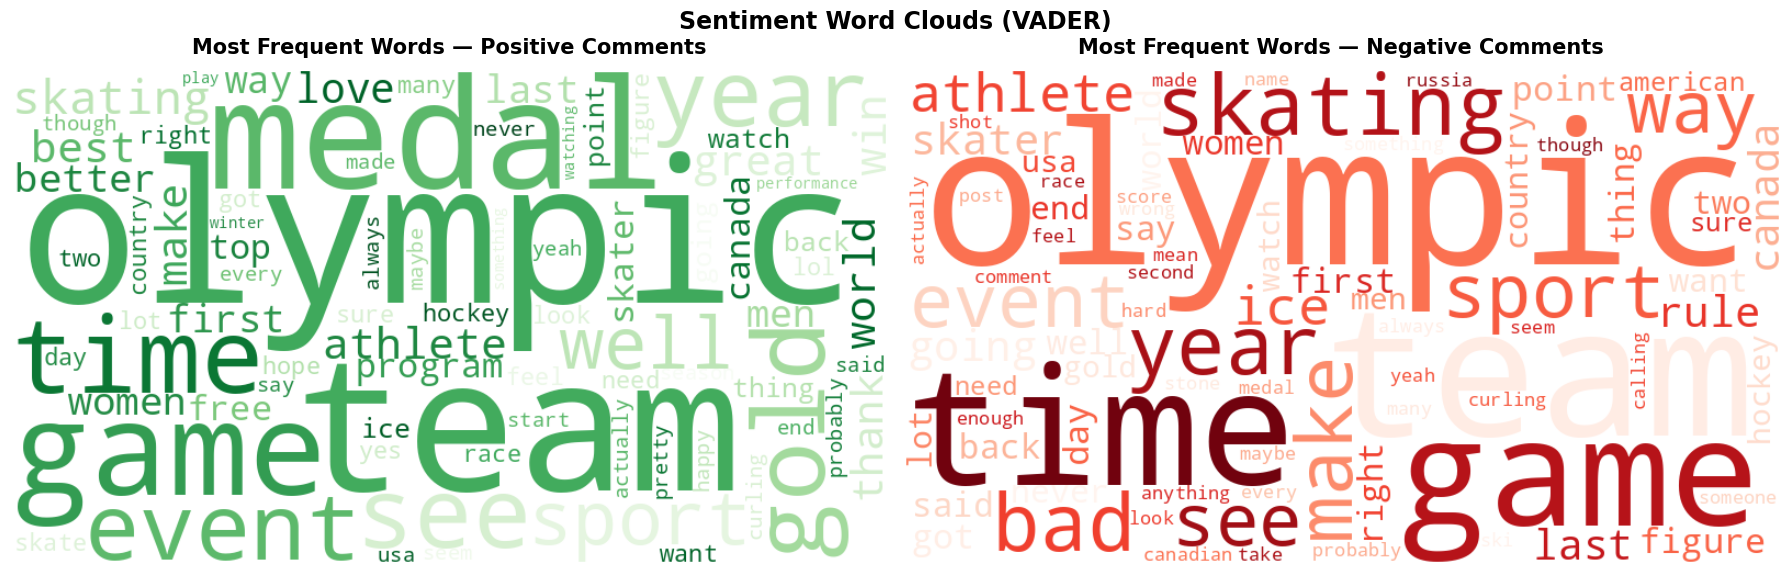

In [ ]:
stop_en = set(stopwords.words('english'))
stop_extra = {'like', 'just', 'would', 'really', 'one', 'get', 'also',
              'even', 'much', 'still', 'go', 'know', 'think', 'good', 'people'}
stop_all = stop_en | stop_extra

def make_corpus(df, label):
    texts = df[df['vader_label'] == label]['text_clean'].dropna()
    words = ' '.join(texts)
    return ' '.join(w for w in words.split() if w not in stop_all and len(w) > 2)

corpus_pos = make_corpus(comments_df, 'positive')
corpus_neg = make_corpus(comments_df, 'negative')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc_pos = WordCloud(
    width=800,
    height=450,
    background_color='white',
    colormap='Greens',
    max_words=80,
    collocations=False
).generate(corpus_pos)

wc_neg = WordCloud(
    width=800,
    height=450,
    background_color='white',
    colormap='Reds',
    max_words=80,
    collocations=False
).generate(corpus_neg)

# Positive word cloud
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title(
    'Most Frequent Words — Positive Comments',
    fontsize=15,
    fontweight='bold',
    pad=12
)

# Negative word cloud
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title(
    'Most Frequent Words — Negative Comments',
    fontsize=15,
    fontweight='bold',
    pad=12
)

plt.suptitle(
    'Sentiment Word Clouds (VADER)',
    fontsize=17,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/wordcloud_pos_neg.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

---
## Summary and saving results

In [ ]:
print(f'Comments analyzed   : {len(comments_df)}')

print(f'\nVADER — label distribution:')
print(comments_df['vader_label'].value_counts().to_string())

print(f'\nRoBERTa — label distribution:')
print(comments_df['roberta_label'].value_counts().to_string())

print(f'\nGlobal VADER Compound: {comments_df["vader_compound"].mean():+.4f}')

print(f'\nSentiment by subreddit (average VADER):')
print(sub_sentiment['vader_mean'].round(4).to_string())  # ← fix qui

print(f'\nVADER vs. RoBERTa Agreement: {agreement:.2%}')

Comments analyzed   : 24756

VADER — label distribution:
vader_label
positive    13652
neutral      5822
negative     5282

RoBERTa — label distribution:
roberta_label
neutral     11027
positive     7312
negative     6417

Global VADER Compound: +0.2329

Sentiment by subreddit (average VADER):
subreddit
skiing           0.0928
Curling          0.1816
hockey           0.1960
snowboarding     0.1988
olympics         0.2144
FigureSkating    0.2676
biathlon         0.3086

VADER vs. RoBERTa Agreement: 57.57%
